# House Price Prediction - Data Cleaning, EDA and Modeling
**Dataset:** House Price by Juhi Bhojani (https://www.kaggle.com/datasets/juhibhojani/house-price)  

In this notebook we will do:
1. Load & Inspect the data
2. Exploratory Data Analysis (EDA)
3. Cleaning & Feature Engineering
4. Build a Pipeline & Train
5. Evaluate
6. Export the Model

### 1. Load & Inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [3]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [6]:
df.isna().mean().sort_values(ascending = False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

- 187531 rows
- Numeric columns (4):
 Index,  Price (in rupees), Dimensions, Plot Area
- Text columns (17):
 Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area
- Dimensions and  Plot Area are entirelly missing columns
- Society, Super Area and Car Parking columns have more than half of their values missing

### 2. Exploratory Data Analysis (EDA)

First, we will clean the target price column and carpet area column.

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None
    
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    m = re.search(r"([\d,.]+)\s*(sqft|sqm|sq\.?ft|sq\.?m)?", x.lower())
    if not m:
        return np.nan
    try:
        val = float(m.group(1).replace(",", ""))
    except ValueError:
        return np.nan
    unit = m.group(2)
    if unit and "sqm" in unit.replace(".", ""):
        val *= 10.764
    return val

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

df['carpet_area_sqft'] = df['carpet_area_sqft'].fillna(df['super_area_sqft'] * 0.75)
df = df.dropna(subset=['carpet_area_sqft'])

- Now, we will show distribution of the target price.   

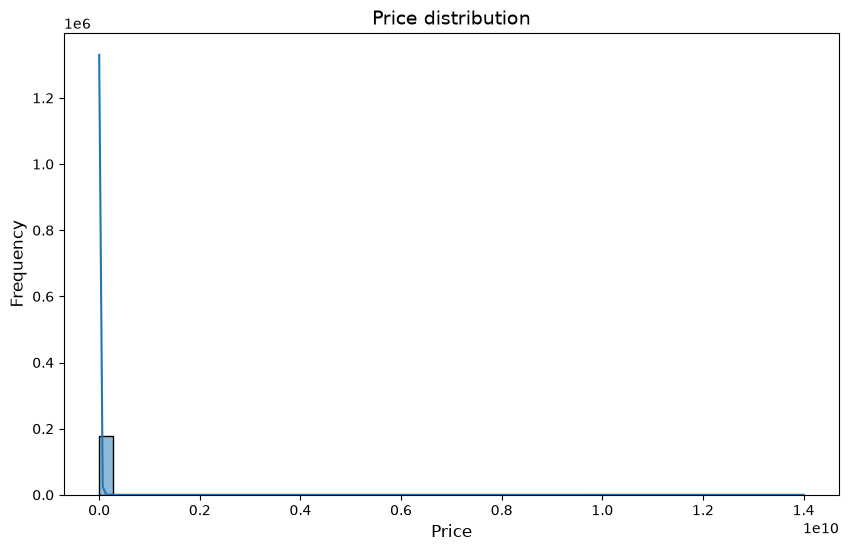

In [9]:
plt.figure(figsize=(10, 6))
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
sns.histplot(df["price_clean"], bins=50, kde=True)
plt.title("Price distribution", fontsize=14)
plt.show()

It is heavily **skewed**, we will try a **log scale**.

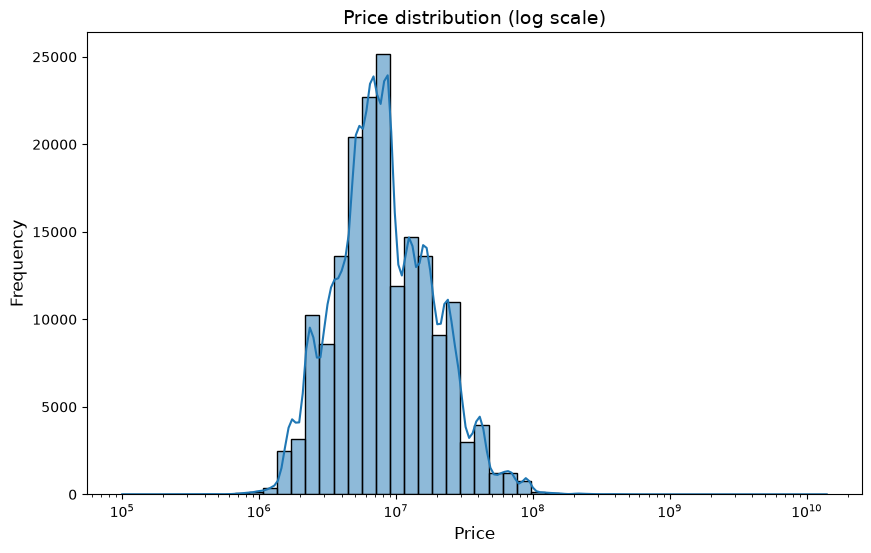

In [10]:
plt.figure(figsize=(10, 6))
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
sns.histplot(df["price_clean"], log_scale=True, bins=50, kde=True)
plt.title("Price distribution (log scale)", fontsize=14)
plt.show()

When we applied **log scale** on the price distribution, it became close to a normal distribution.

- Next, price vs. carpet area:

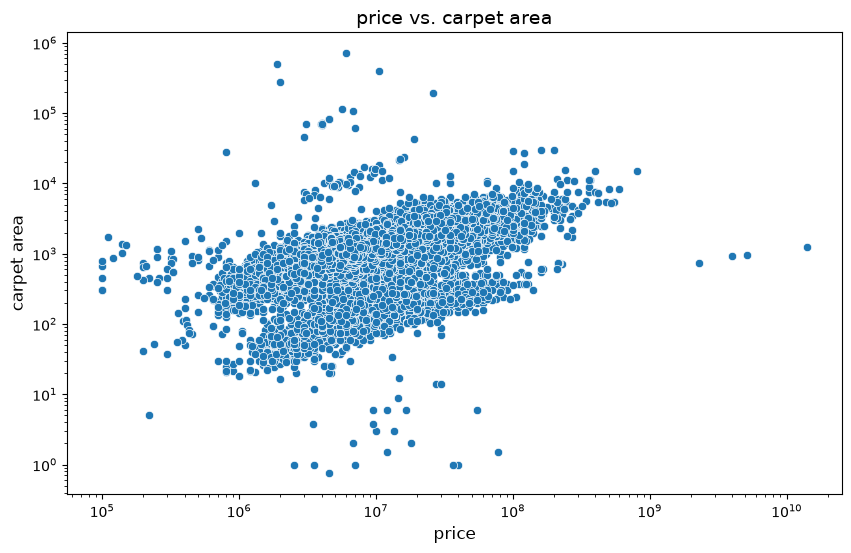

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x = df["price_clean"], y = df["carpet_area_sqft"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel('price', fontsize=12)
plt.ylabel('carpet area', fontsize=12)
plt.title('price vs. carpet area', fontsize=14)
plt.show()

There's a clear positive correlation between price and carpet area.

- Average price by top-15 locations:

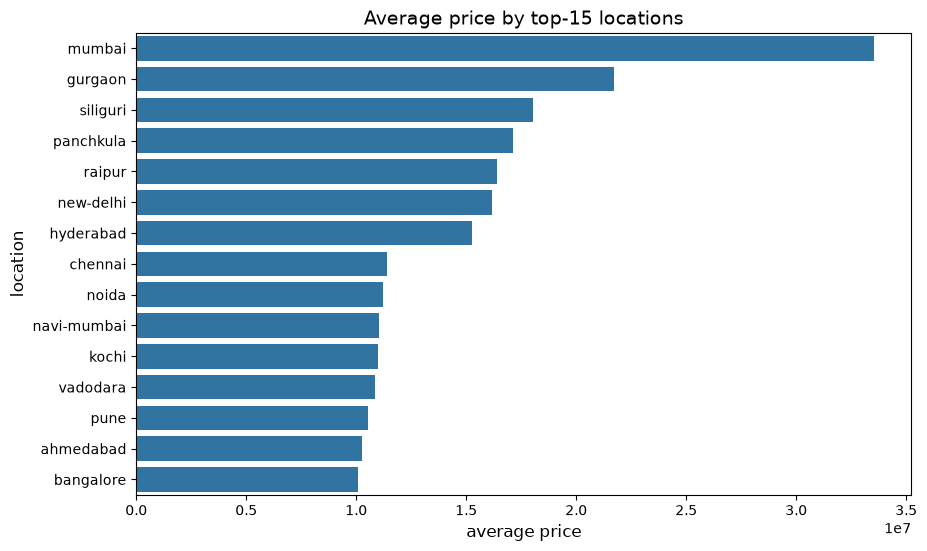

In [12]:
top15 = df['price_clean'].groupby(df['location']).mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index)
plt.xlabel("average price", fontsize=12)
plt.ylabel("location", fontsize=12 )
plt.title("Average price by top-15 locations", fontsize=14)
plt.show()

Average price varies by location — the priciest localities are multiple times more expensive than the cheapest, making location a key predictor for house price estimation.

- Price by furnishing status, number of bathrooms:

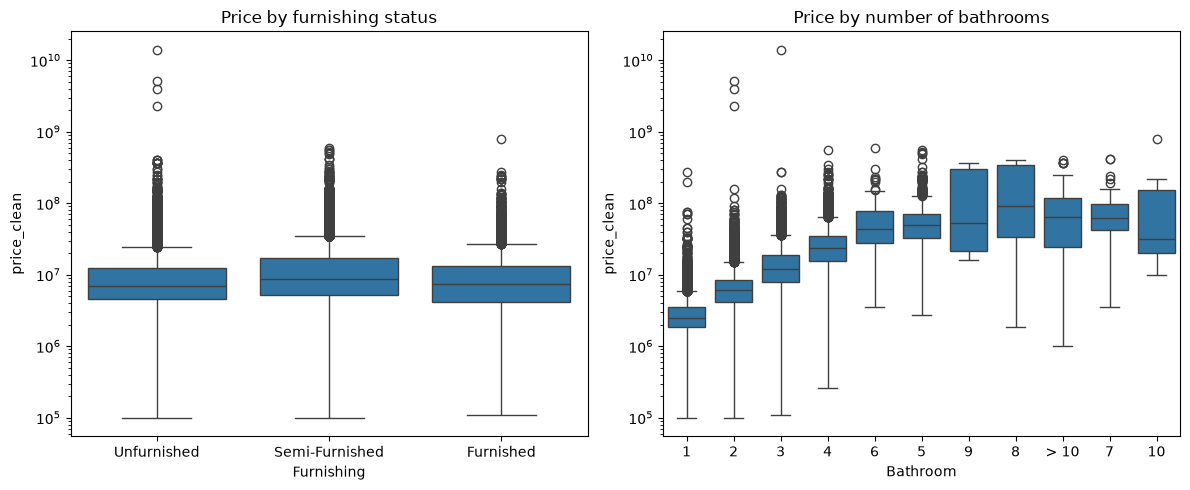

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df["Furnishing"], y=df["price_clean"], ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")

sns.boxplot(x=df["Bathroom"], y=df["price_clean"], ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

Furnishing status has a small impact on the overall property price, as median prices across Unfurnished, Semi-Furnished, and Furnished statuses remain relatively close.

Number of bathrooms shows a strong positive correlation with price. As the number of bathrooms increases, the median price rises significantly, making Bathroom a key predictor for house price estimation.

### 3. Cleaning & Feature Engineering

In [14]:
def parse_floor(x):
    if pd.isna(x):
        return None
    if 'Ground' in x:
        return 0
    if 'Basement' in x:
        return -1
    m = re.search(r'(\d+)', x)
    if m:
        return int(m.group(1))
    else:
        return np.nan

df['floor_num'] = df['Floor'].apply(parse_floor).astype('Int64')

In [15]:
for col in ['Bathroom', 'Balcony', 'Car Parking']:
    df[col] = df[col].str.extract(r'(\d+)')[0]
    df[col] = pd.to_numeric(df[col])
    df[col] = df[col].fillna(df[col].median()).astype('Int64')

In [16]:
top_N = 50
top_locations = df['location'].value_counts().head(top_N).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

In [17]:
df = df.drop(columns=[
    'Index', 'Title', 'Description', 'Dimensions', 'Plot Area',
    'super_area_sqft', 'Super Area', 'Carpet Area', 'Price (in rupees)',
    'Amount(in rupees)', 'Floor', 'location', 'Society'])

In [18]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])

### 4. Build a Pipeline & Train

In [19]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [20]:
numeric_features = ["carpet_area_sqft", "floor_num", "Bathroom", "Balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

In [21]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ])

In [22]:
X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

In [23]:
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(X, y, y_log, test_size=0.2, random_state=42)

In [24]:
model1 = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())])

model1_log = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())])

In [25]:
model1.fit(X_train, y_train)

model1_log.fit(X_train, y_log_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','Bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [26]:
pred1 = model1.predict(X_test)
print(pred1)

[-2237380.31297491 17579266.93783136  6314368.82639574 ...
 20258350.0291591   7501396.5854424  19933941.19839982]


In [27]:
pred1_log = np.expm1(model1_log.predict(X_test))
print(pred1_log)

[ 4083381.86126874 13682898.09639015  6016101.89177452 ...
 13245697.58053609  7462404.42744635 16378305.24892962]


- Standard Model (pred1): Predicts negative house prices, which is mathematically possible with Linear Regression on skewed data but logically impossible in real estate.

- Log-Transformed Model (pred1_log): Using np.log1p() during training and np.expm1() during prediction completely eliminates negative predictions, handles target skewness effectively, and yields far more realistic price estimates.

**Conclusion:** Log transformation on the target variable (price_clean) significantly improves the model's reliability and stability.


In [28]:
model2 = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, max_samples=0.5, max_depth=10, n_jobs=-1, random_state=42))])

model2.fit(X_train, y_log_train)

pred2_log = np.expm1(model2.predict(X_test))

In [29]:
model3 = Pipeline([
    ("prep", preprocessor),
    ("reg", GradientBoostingRegressor(random_state=42))])

model3.fit(X_train, y_log_train)

pred3_log = np.expm1(model3.predict(X_test))

### 5. Evaluate

In [30]:
mae_LR = mean_absolute_error(y_test, pred1_log)
rmse_LR = root_mean_squared_error(y_test, pred1_log)
r2_LR = r2_score(y_test, pred1_log)
print(f"Model1: Linear Regression:\nMAE : {mae_LR}\nRMSE : {rmse_LR}\nR2 : {r2_LR}")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_LR = cross_val_score(model1_log, X_train, y_log_train, cv=kfold, scoring='r2')
mean_scores_LR = np.mean(scores_LR)
print("Accuracy scores for each fold:", scores_LR)
print("Mean Accuracy:", mean_scores_LR)

Model1: Linear Regression:
MAE : 893643784.1119564
RMSE : 165061653122.76694
R2 : -149340292.7832955
Accuracy scores for each fold: [0.72359371 0.71869871 0.71369703 0.72280105 0.73701477]
Mean Accuracy: 0.7231610531783927


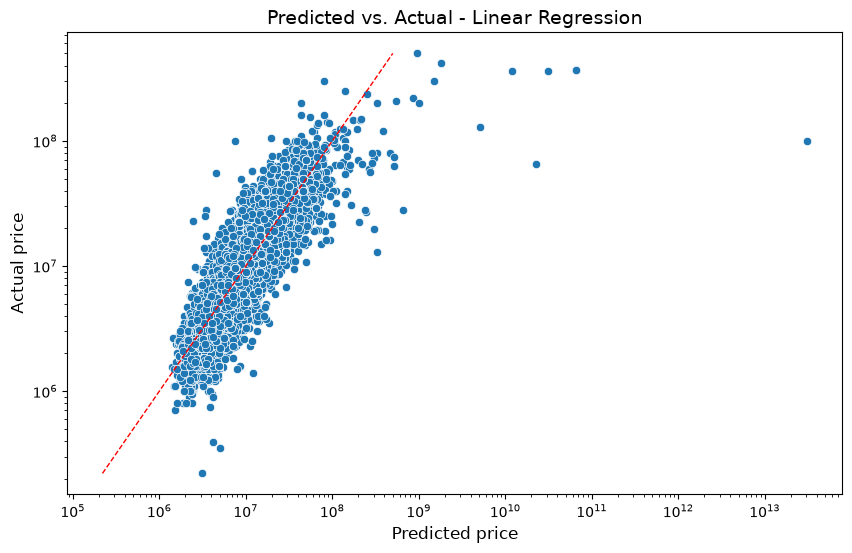

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x = pred1_log, y = y_test)
plt.xscale("log")
plt.yscale("log")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel('Predicted price', fontsize=12)
plt.ylabel('Actual price', fontsize=12)
plt.title('Predicted vs. Actual - Linear Regression', fontsize=14)
plt.show()

In [32]:
mae_RF = mean_absolute_error(y_test, pred2_log)
rmse_RF = root_mean_squared_error(y_test, pred2_log)
r2_RF = r2_score(y_test, pred2_log)
print(f"Model2: Random Forest\nMAE : {mae_RF}\nRMSE : {rmse_RF}\nR2 : {r2_RF}")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_RF = cross_val_score(model2, X_train, y_log_train, cv=kfold, scoring='r2')
mean_scores_RF = np.mean(scores_RF)
print("Accuracy scores for each fold:", scores_RF)
print("Mean Accuracy:", mean_scores_RF)

Model2: Random Forest
MAE : 1679184.227307732
RMSE : 4706307.66973857
R2 : 0.8785925740890219
Accuracy scores for each fold: [0.88966402 0.8913327  0.88683628 0.890326   0.8926416 ]
Mean Accuracy: 0.8901601197775358


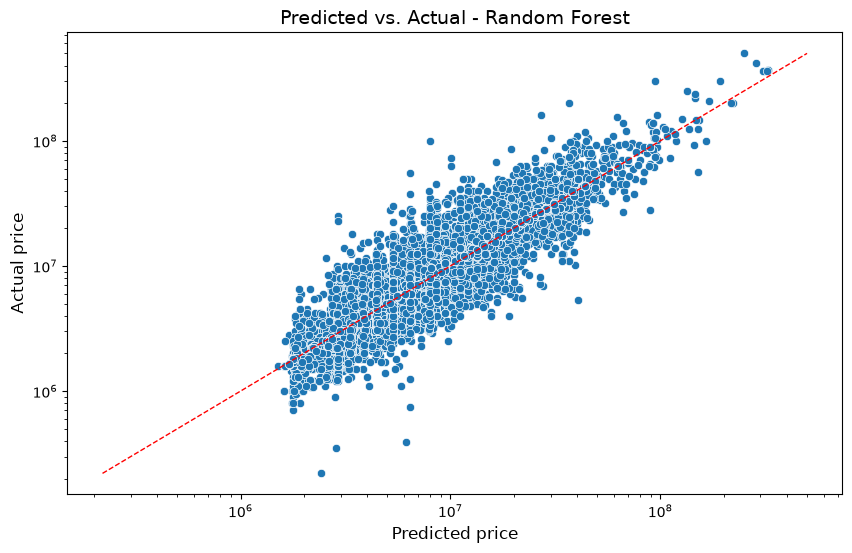

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x = pred2_log, y = y_test)
plt.xscale("log")
plt.yscale("log")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel('Predicted price', fontsize=12)
plt.ylabel('Actual price', fontsize=12)
plt.title('Predicted vs. Actual - Random Forest', fontsize=14)
plt.show()

In [34]:
mae_GB = mean_absolute_error(y_test, pred3_log)
rmse_GB = root_mean_squared_error(y_test, pred3_log)
r2_GB = r2_score(y_test, pred3_log)
print(f"Model3: Gradient Boosting:\nMAE : {mae_GB}\nRMSE : {rmse_GB}\nR2 : {r2_GB}")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_GB = cross_val_score(model3, X_train, y_log_train, cv=kfold, scoring='r2')
mean_scores_GB = np.mean(scores_GB)
print("Accuracy scores for each fold:", scores_GB)
print("Mean Accuracy:", mean_scores_GB)

Model3: Gradient Boosting:
MAE : 2971194.6200724104
RMSE : 6956505.4679718455
R2 : 0.7347429824123657
Accuracy scores for each fold: [0.83404223 0.83316139 0.83090789 0.83046143 0.83625944]
Mean Accuracy: 0.8329664766950016


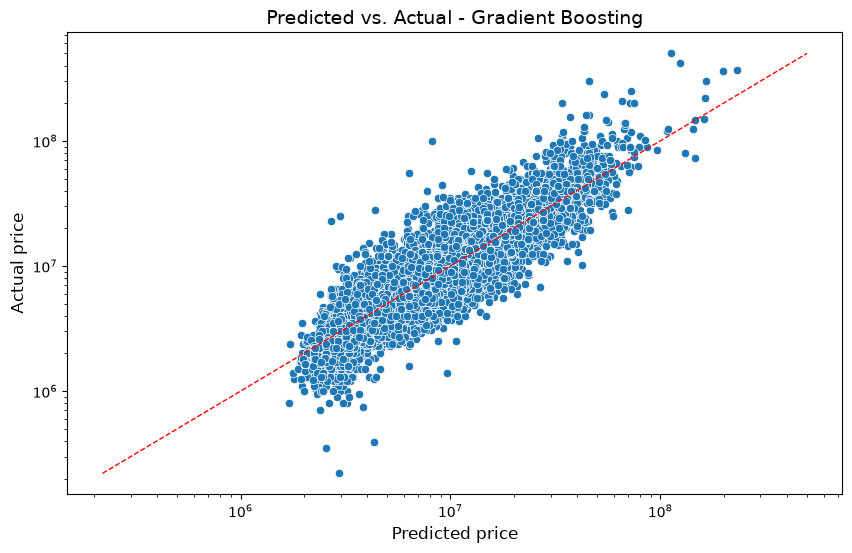

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x = pred3_log, y = y_test)
plt.xscale("log")
plt.yscale("log")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel('Predicted price', fontsize=12)
plt.ylabel('Actual price', fontsize=12)
plt.title('Predicted vs. Actual - Gradient Boosting', fontsize=14)
plt.show()

In [36]:
comparison_model = pd.DataFrame({
    'Linear Regression': [mae_LR, rmse_LR, r2_LR, mean_scores_LR],
    'Random Forest': [mae_RF, rmse_RF, r2_RF, mean_scores_RF],
    'Gradient Boosting': [mae_GB, rmse_GB, r2_GB, mean_scores_GB]},
    index = ['MAE', 'RMSE', 'R2', 'CV Score'])

print(comparison_model)

          Linear Regression  Random Forest  Gradient Boosting
MAE            8.936438e+08   1.679184e+06       2.971195e+06
RMSE           1.650617e+11   4.706308e+06       6.956505e+06
R2            -1.493403e+08   8.785926e-01       7.347430e-01
CV Score       7.231611e-01   8.901601e-01       8.329665e-01


In [37]:
print(comparison_model.loc['MAE'].idxmin())
print(comparison_model.loc['RMSE'].idxmin())
print(comparison_model.loc['R2'].idxmax())
print(comparison_model.loc['CV Score'].idxmax())

Random Forest
Random Forest
Random Forest
Random Forest


**Random Forest** is the best model over Linear Regression and Gradient Boosting across all evaluation metrics:  
- The lowest MAE and RMS
- The highest test R² and the highest 5-fold CV R²

### 6. Export the Model

In [38]:
import joblib
import json

In [39]:
joblib.dump(model2, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [15.63908409]


In [40]:
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))